# **Machine Learning Studies (Week of September 14 - September 20)**

SDLC (Software Development Lifecycle)

***How a problem should be approached***

* Problem formation and understanding
  * Is machine learning an ethical solution?
  * Inputs and outputs
  * What is the acceptable threshold of errors for this circumstance?
  * What am I expecting from accuracy? (Number of correct predictions over the total number of predictions)
* Data collection and preparation
  * Select your data from different sources
  * Clean your data by removing outliers and irrelevant features
  * Transform data to be in an appropriate format for your goal
* Model training and testing
  * Split the data into Training, Validation, and Test.
  * I've seen 80% for training, 10% for validation, and 10% for testing, but have also seen 70% for training, 20% for validation, and 10% for testing.
  * Iterate and experiment
  * Fine-tuning
  * Evaluation of the model
* Model deployment and maintenance
  * Periodically retraining and monitoring overall progress.

## **When can Machine Learning shine?**

* Predicting an outcome
* Uncover trends and patterns in data
* Your dataset is too large to process by a human

***How can I frame a problem?***

Questions for my model --> Required inputs and expected outputs --> Choose the algorithm --> Check your dataset --> Analyze features that can be potentially more
relevant to the model (try and explore)

***Custom Machine Learning model***

It can be built with a large enough dataset + enough compute processing power. Low level (simple) models can be built using local CPUs, whereas high level (complex) models require stronger GPUs, commonly outsourced from cloud providers.

***Machine Learning Framework Libraries***

* Scikit-learn
* TensorFlow
* MXNext
* PyTorch
* Keras

***Supervised Learning***

A machine learning type that is trained on labeled data.

* Contains target values that the machine learns to predict












## Project: Predict Home Costs

For this problem, I will be using linear regression since the goal is to predict a continuous variable.

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
# Reading the dataset
housing_df = pd.read_csv("housing.csv")

# Using .info() to see which features are available and what their data types are
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Text(0.5, 0, 'House Values')

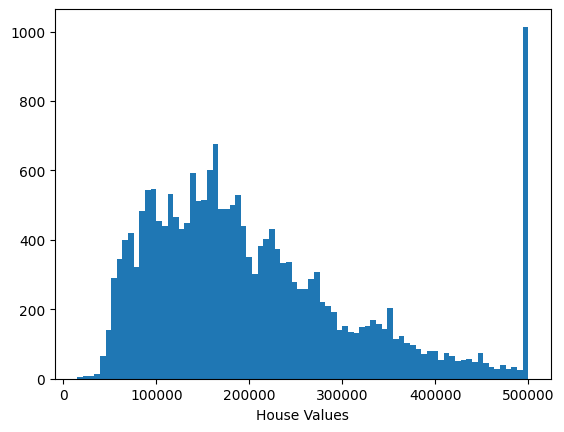

In [60]:
# Visualizing the data using a histogram
plt.hist(housing_df['median_house_value'], bins=80) # bins represents the amount of columns
plt.xlabel("House Values")

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

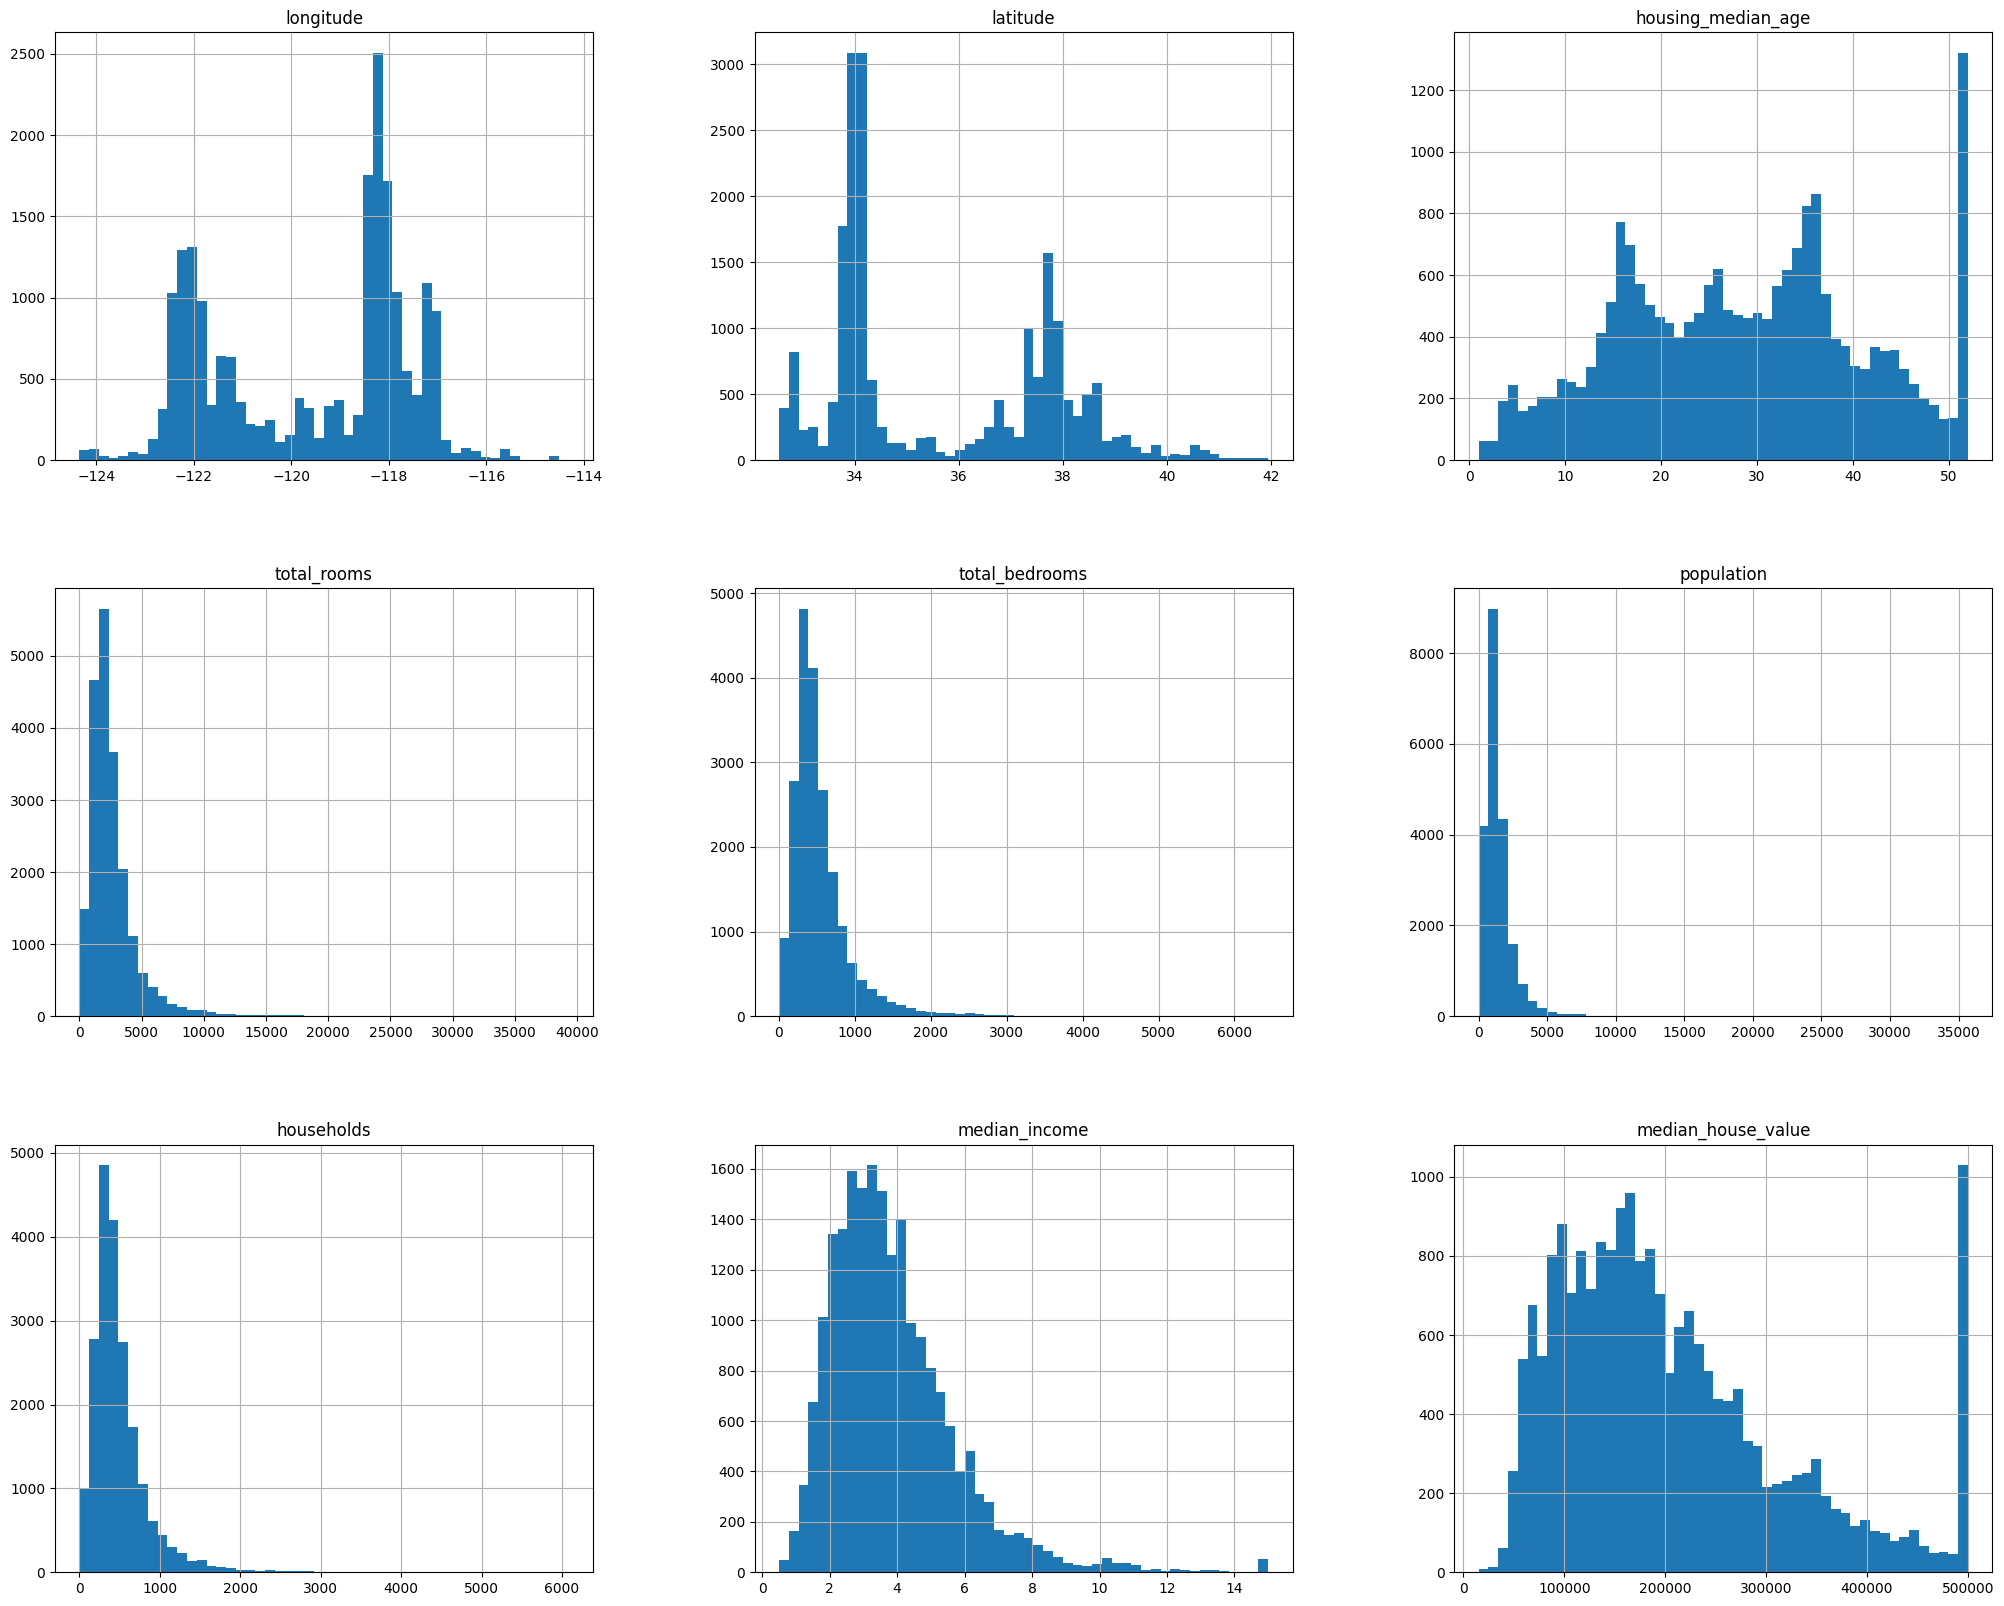

In [61]:
# Visualizing other features using a histogram
# Pandas automatically skips OCEAN PROXIMITY since it is categorical rather than numerical
housing_df.hist(bins=50, figsize=(25, 20))

Through these histograms, we can identify graphically two important features that I will use to predict housing prices: housing_median_age and median_house_value, both presenting outliers at their maximum values. A problem I will fix later.

In order to understand the correlation among these features, I will use a heatmap.

In [62]:
# Plot a graphical correlation matrix for each pair of columns in the dataframe

corr = housing_df.corr(numeric_only=True) # DataFrame correlation function, containing only numeric values
print(corr)

                    longitude  latitude  housing_median_age  total_rooms  \
longitude            1.000000 -0.924664           -0.108197     0.044568   
latitude            -0.924664  1.000000            0.011173    -0.036100   
housing_median_age  -0.108197  0.011173            1.000000    -0.361262   
total_rooms          0.044568 -0.036100           -0.361262     1.000000   
total_bedrooms       0.069608 -0.066983           -0.320451     0.930380   
population           0.099773 -0.108785           -0.296244     0.857126   
households           0.055310 -0.071035           -0.302916     0.918484   
median_income       -0.015176 -0.079809           -0.119034     0.198050   
median_house_value  -0.045967 -0.144160            0.105623     0.134153   

                    total_bedrooms  population  households  median_income  \
longitude                 0.069608    0.099773    0.055310      -0.015176   
latitude                 -0.066983   -0.108785   -0.071035      -0.079809   
housing_

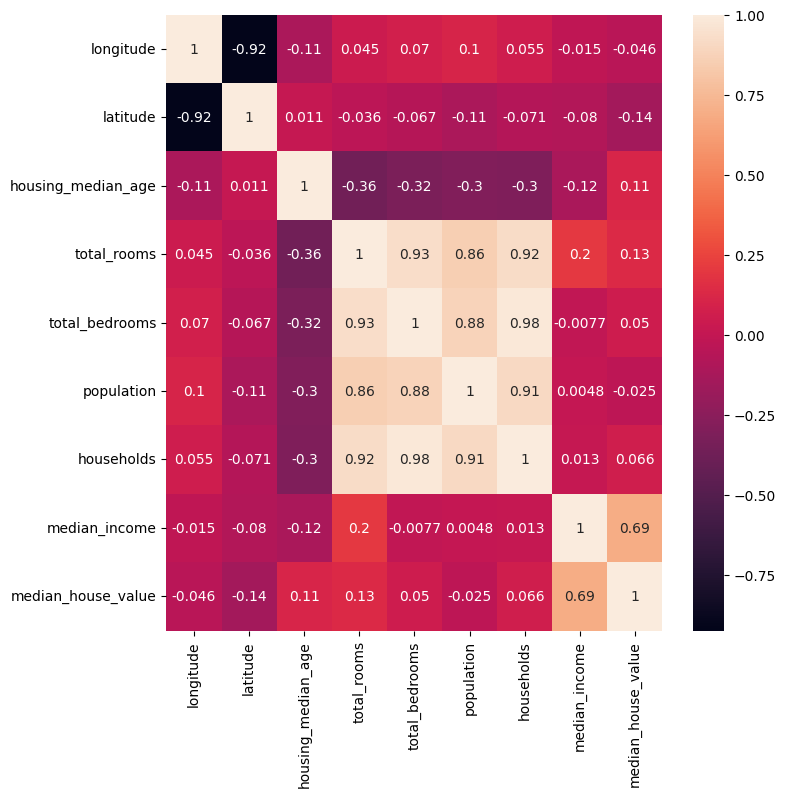

In [63]:
# Altering the heatmap size
plt.figure(figsize=(8,8))

sns.heatmap(corr, annot=True)
plt.show()

When reading a heatmap, pay attention to the numerical values. More precisely, pay attention to how they correlate with each other; values closer to 1 or -1 demonstrate higher correlation, and values closer to 0 demonstrate lower correlation.

***Positive correlation***: if one variable increases, the other tends to increase as well.

***Negative correlation:*** if one variable increases, the other tends to decrease.

## Feature Engineering

* Manipulates data
* Adds, removes, and combines features
* Creates new features

Everything is done aiming at improving model predictions.


In [64]:
from sklearn.impute import KNNImputer

# Create a temporary copy of the dataset
housing_df_temp = housing_df.copy()

# Retrieve columns with numerical data; will exclude the ocean_proximity since it is a categorical value
columns_list = [col for col in housing_df_temp.columns if housing_df_temp[col].dtype != 'object']

# Extract columns that contain at least one missing value
new_column_list = [col for col in housing_df_temp.loc[:, housing_df_temp.isnull().any()]]

# Update temp dataframe with numeric columns that have empty values
housing_df_temp = housing_df_temp[new_column_list]

Impute missing data using ML

In [65]:
# Initialize KNNImputer to impute missing data using ML
knn = KNNImputer(n_neighbors = 3)

# Fit function trains the model
knn.fit(housing_df_temp)

# Transform the data using the model
# Applies the tranformation model (ie knn) to data
array_Values = knn.transform(housing_df_temp)

# Convert the array values to a dataframe with the appropriate column names
housing_df_temp = pd.DataFrame(array_Values, columns = new_column_list)

In [66]:
# Confirm there are no columns with missing values
housing_df_temp.isnull().sum()

,0
total_bedrooms,0


In [67]:
# Overlay the imputed column over the old column with missing values.

# Loop through the list of columns and overlay each one
for column_name in new_column_list:
  housing_df[column_name] = housing_df_temp[column_name]

# Confirm columns no longer contain null data
housing_df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [68]:
# Creating new features

# A new feature that is a ratio of the total rooms to households
housing_df['rooms_per_household'] = housing_df['total_bedrooms']/housing_df['households']

# A new feature that is a ratio of the total bedrooms to the total rooms
housing_df['bedrooms_per_room'] = housing_df['total_bedrooms']/housing_df['total_rooms']

# A new feature that is a ratio of the population to the households
housing_df['population_per_household'] = housing_df['population']/housing_df['households']

# Combine the latitue and longitude into one
housing_df['coords'] = housing_df['longitude']/housing_df['latitude']

housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 20640 non-null  float64
 1   latitude                  20640 non-null  float64
 2   housing_median_age        20640 non-null  float64
 3   total_rooms               20640 non-null  float64
 4   total_bedrooms            20640 non-null  float64
 5   population                20640 non-null  float64
 6   households                20640 non-null  float64
 7   median_income             20640 non-null  float64
 8   median_house_value        20640 non-null  float64
 9   ocean_proximity           20640 non-null  object 
 10  rooms_per_household       20640 non-null  float64
 11  bedrooms_per_room         20640 non-null  float64
 12  population_per_household  20640 non-null  float64
 13  coords                    20640 non-null  float64
dtypes: flo

In [69]:
# Removing correlate features
housing_df.drop(columns=['total_rooms', 'households', 'total_bedrooms', 'population', 'longitude', 'latitude'], axis=1, inplace=True)

housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   housing_median_age        20640 non-null  float64
 1   median_income             20640 non-null  float64
 2   median_house_value        20640 non-null  float64
 3   ocean_proximity           20640 non-null  object 
 4   rooms_per_household       20640 non-null  float64
 5   bedrooms_per_room         20640 non-null  float64
 6   population_per_household  20640 non-null  float64
 7   coords                    20640 non-null  float64
dtypes: float64(7), object(1)
memory usage: 1.3+ MB


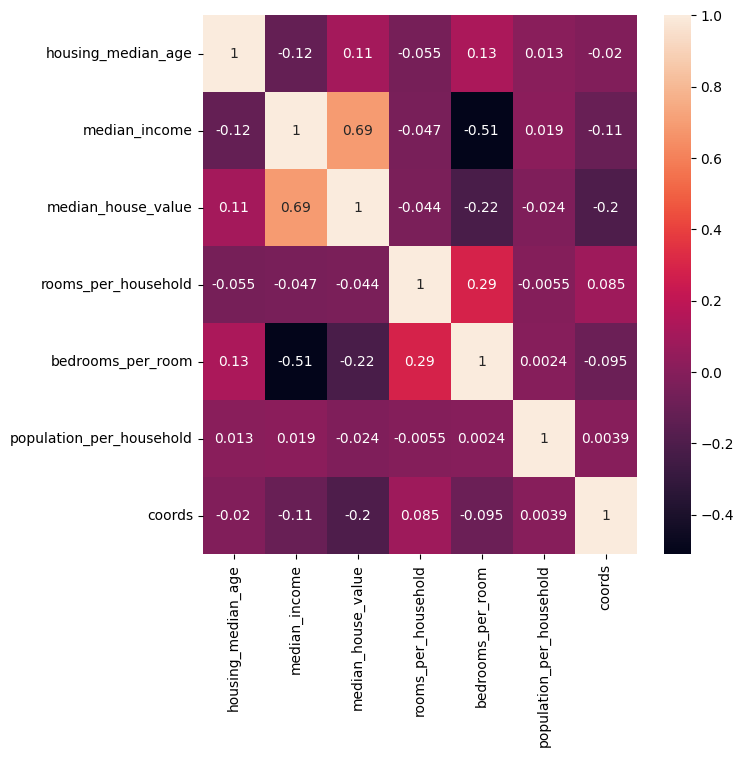

In [70]:
corr = housing_df.corr(numeric_only=True)

# Make the heatmap  larger in size
plt.figure(figsize= (7,7))

sns.heatmap(corr, annot=True)
plt.show()

Most machine learning algorithms can only learn from numerical data, so it is time to convert the only categorical data we have - Ocean Proximity - to numerical using One-Hot Encoding technique.

In [71]:
print(pd.get_dummies(housing_df['ocean_proximity'])) # Creates a binary column

       <1H OCEAN  INLAND  ISLAND  NEAR BAY  NEAR OCEAN
0          False   False   False      True       False
1          False   False   False      True       False
2          False   False   False      True       False
3          False   False   False      True       False
4          False   False   False      True       False
...          ...     ...     ...       ...         ...
20635      False    True   False     False       False
20636      False    True   False     False       False
20637      False    True   False     False       False
20638      False    True   False     False       False
20639      False    True   False     False       False

[20640 rows x 5 columns]


In [72]:
# Replacing the OCEAN_PROXIMITY column using get_dummies()

housing_df_encoded = pd.get_dummies(data=housing_df, columns=['ocean_proximity'])

# Print first few observations of the new dataframe
housing_df_encoded.head()

,housing_median_age,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,coords,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,41.0,8.3252,452600.0,1.023810,0.146591,2.555556,-3.226769,False,False,False,True,False
1,21.0,8.3014,358500.0,0.971880,0.155797,2.109842,-3.228209,False,False,False,True,False
2,52.0,7.2574,352100.0,1.073446,0.129516,2.802260,-3.229590,False,False,False,True,False
3,52.0,5.6431,341300.0,1.073059,0.184458,2.547945,-3.229855,False,False,False,True,False
4,52.0,3.8462,342200.0,1.081081,0.172096,2.181467,-3.229855,False,False,False,True,False


Notes: As features increase it's harder for the model to learn, and adding features can increase training costs.